# CatBoost на полном наборе «сырых» признаков (новые клиенты)

В `03_advanced_models.ipynb` мы обучали CatBoost на ~20 инженерных признаках из `features.yaml` — тех же, что и LogReg. Результат: CatBoost лишь на уровне LogReg (ROC-AUC 0.871 test, 0.852 val).

**Гипотеза:** LogReg-ориентированный feature engineering (бины, группировки, target encoding) *ограничивает* CatBoost. Бустинг нативно обрабатывает категории и находит пороги — ему не нужны ручные бины и группировки. Дадим ему **все ~50 сырых признаков** из датасета (за вычетом утечек и мусора) и посмотрим, сможет ли он найти сигнал, который мы упустили.

**Что убираем:**
1. **Data leakage** — признаки, заполняемые после исхода заказа (при возврате/отказе)
2. **Уникальные ID** — `lead_id`, `contact_id`, телефоны, трек-номера, адреса
3. **Почти пустые** — >95% NaN или >99% одно значение
4. **Свободный текст** — комментарии, составы заказов, cookies
5. **Target и outcome** — `buyout_flag` (таргет), `outcome_unknown`, timestamps исходов

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, matthews_corrcoef,
    ConfusionMatrixDisplay, roc_curve,
)
from catboost import CatBoostClassifier, Pool
import optuna

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

SEED = 42
target = 'buyout_flag'

## 1. Загрузка и фильтрация данных

In [2]:
df_raw = pd.read_csv('dataset_2025-03-01_2026-03-29_external.csv', low_memory=False)
print(f'Исходный датасет: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов')

# Фильтруем: только новые клиенты, исключаем outcome_unknown
new_mask = df_raw['contact_Число сделок'].isna() | (df_raw['contact_Число сделок'] < 1)
df = df_raw[new_mask & ~df_raw['outcome_unknown']].copy()
df[target] = df[target].astype(int)
print(f'Новые клиенты (без outcome_unknown): {len(df)} строк')
print(f'Buyout rate: {df[target].mean():.3f}')

Исходный датасет: 18887 строк, 191 столбцов
Новые клиенты (без outcome_unknown): 4079 строк
Buyout rate: 0.325


## 2. Удаление утечек, уникальных ID и мусора

Подробный анализ утечек — в `feature_recommendations.md`, разделы 6-7.

In [3]:
# === DATA LEAKAGE ===
# Признаки, заполняемые ПОСЛЕ исхода заказа (при возврате/отказе/получении)
LEAKAGE = [
    # Outcome columns
    'outcome_unknown',
    'handed_to_delivery_ts', 'issued_or_pvz_ts', 'received_ts',
    'rejected_ts', 'returned_ts',
    'days_sale_to_handed', 'days_handed_to_issued_pvz', 'days_to_outcome',
    'lifecycle_incomplete', 'current_status_id', 'closed_ts',
    # CRM-поля, обновляемые после исхода
    'lead_status_id', 'lead_loss_reason_id', 'lead_closed_at', 'lead_updated_at',
    'lead_is_deleted',
    # Набор 2 размеров (заполняются при возврате, filled buyout ~9%)
    'lead_Вес (грамм)*', 'lead_Длина', 'lead_Ширина', 'lead_Высота',
    # CRM-даты, заполняемые после исхода
    'lead_Дата перехода Передан в доставку',
    'lead_Дата перехода в Сборку',
    'lead_Ответственный за доставку',
    'lead_LEADQUALIFYCATION',
    # Пост-отправочные поля
    'lead_Условный отказ',
    'lead_Оплачено клиентом',
    'lead_Дата получения денег на Р/С',
    'lead_Дата возврата посылки на склад',
    'lead_Статус заказа на сайте',
    # Дополнительные утечки (обнаружены при анализе filled/NaN buyout rate):
    # lead_Дата создания сделки: nan=62%, filled buyout=8.9% — заполняется при возврате
    'lead_Дата создания сделки',
    # lead_ROISTAT_REFERRER: nan=63%, filled buyout=18% — обратная полярность
    'lead_ROISTAT_REFERRER',
    # contact_LTV, contact_Число сделок — знаем что новые (=0), не информативно
    'contact_LTV', 'contact_Число сделок',
    # contact_updated_at — обновляется после исхода
    'contact_updated_at',
]

# === ДУБЛИКАТЫ lead_price (r=0.997) ===
PRICE_DUPLICATES = [
    'lead_Объявленная ценность (руб)',
    'lead_Сумма наложенного платежа (руб)',
]

# === UNIQUE IDs / FREE TEXT / ADDRESSES ===
UNIQUE_OR_TEXT = [
    'lead_id', 'lead_name',
    'contact_id', 'contact_name', 'contact_first_name', 'contact_last_name',
    'contact_Телефон', 'contact_Email',
    'lead_TRANID', 'lead_roistat', 'lead_clientID',
    'lead__ym_uid', 'lead_yclid',
    'lead_COOKIES', 'lead_REFERER',
    'lead_Номер отправления СДЭК', 'lead_Трек-номер', 'lead_Трек-номер СДЭК',
    'lead_Ссылка на бланк отправления',
    'lead_Адрес получателя', 'lead_Адрес подробно',
    'lead_Адрес доставки', 'lead_Полный адрес',
    'contact_Адрес клиента', 'contact_Адрес ПВЗ',
    'lead_Комментарий', 'lead_Комментарий к заказу', 'contact_Комментарии',
    'lead_Комментарий к отправлению',
    'lead_Состав заказа',  # свободный текст (cart_n_items вычислим отдельно)
    'lead_Наименование получателя', 'lead_ФИО',
    'lead_tags',  # 1200+ уникальных, содержит утечки ('отказ', 'НДЗ')
    'lead_Нумерация сделки',  # уникальный ID
    'contact_Трекинг',  # уникальный трекинг
    'lead_ROISTAT_FIELDS_ROISTAT',  # уникальный roistat ID
    'contact_Код ПВЗ',  # ~5000 уникальных кодов ПВЗ
    'lead_Номер заказа на сайте',
]

# Собираем все колонки для удаления (НЕ включаем target!)
drop_cols = set(LEAKAGE + PRICE_DUPLICATES + UNIQUE_OR_TEXT)

# Удаляем также колонки с >95% NaN или <=1 уникальным значением
for c in df.columns:
    if c in drop_cols or c == target:
        continue
    nan_pct = df[c].isna().mean()
    nunique = df[c].nunique()
    if nan_pct > 0.95:
        drop_cols.add(c)
    elif nunique <= 1:
        drop_cols.add(c)

# Удаляем (target остаётся!)
existing_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=existing_drop)

print(f'Удалено столбцов: {len(existing_drop)}')
print(f'Осталось: {df.shape[1]} столбцов (включая target)')
print()
print('Оставшиеся столбцы:')
for c in df.columns:
    if c == target:
        print(f'  {c:<50} [TARGET]')
        continue
    nan_pct = df[c].isna().mean() * 100
    nunique = df[c].nunique()
    print(f'  {c:<50} nan={nan_pct:5.1f}%  nunique={nunique:>5}  dtype={df[c].dtype}')

Удалено столбцов: 147
Осталось: 44 столбцов (включая target)

Оставшиеся столбцы:
  sale_ts                                            nan=  0.0%  nunique= 4064  dtype=int64
  sale_date                                          nan=  0.0%  nunique=  389  dtype=object
  buyout_flag                                        [TARGET]
  lead_price                                         nan=  0.0%  nunique= 2344  dtype=int64
  lead_responsible_user_id                           nan=  0.0%  nunique=   27  dtype=object
  lead_group_id                                      nan=  0.0%  nunique=    5  dtype=int64
  lead_pipeline_id                                   nan=  0.0%  nunique=    4  dtype=int64
  lead_created_at                                    nan=  0.0%  nunique= 4077  dtype=int64
  lead_utm_source                                    nan= 23.9%  nunique=   21  dtype=object
  lead_utm_medium                                    nan= 23.9%  nunique=    6  dtype=object
  lead_utm_campaign     

## 3. Feature engineering

Добавляем несколько производных признаков, которые CatBoost не может вычислить сам:
- `sale_delta` — время от создания лида до продажи (дни)
- `sale_weekday`, `sale_hour` — день недели и час продажи
- `cart_n_items` — число товаров в заказе (из `lead_Состав заказа`)
- `has_delivery_info` — заполнены ли поля доставки (Масса не NaN)

In [4]:
# sale_delta (дни)
df['sale_delta'] = (df['sale_ts'] - df['lead_created_at']).clip(lower=0) / 86400

# sale_weekday, sale_hour
sale_dt = pd.to_datetime(df['sale_ts'], unit='s')
df['sale_weekday'] = sale_dt.dt.dayofweek.astype(str)
df['sale_hour'] = sale_dt.dt.hour

# cart_n_items — число товаров из lead_Состав заказа (если он был загружен до drop)
# Загружаем оригинальную колонку обратно
_raw_orders = pd.read_csv('dataset_2025-03-01_2026-03-29_external.csv',
                           usecols=['lead_id', 'lead_Состав заказа'], low_memory=False)
_raw_orders = _raw_orders.set_index('lead_id')

# Считаем из оригинала по lead_id
_order_col = df_raw.loc[df.index, 'lead_Состав заказа']
def count_items(text):
    if pd.isna(text):
        return 0
    tokens = []
    for part in str(text).replace('\n', ';').split(';'):
        part = part.strip()
        if part and 'доставк' not in part.lower():
            tokens.append(part)
    return max(len(tokens), 1) if tokens else 0

df['cart_n_items'] = _order_col.apply(count_items)

# has_delivery_info — Масса (гр) не NaN (Набор 1, НЕ утечка)
_mass_col = df_raw.loc[df.index, 'lead_Масса (гр)']
df['has_delivery_info'] = _mass_col.notna().astype(int)

# Удаляем исходные timestamps (оставляем производные)
df = df.drop(columns=['sale_ts', 'lead_created_at', 'sale_date'], errors='ignore')

print(f'После feature engineering: {df.shape[1]} столбцов')
print(f'Новые: sale_delta, sale_weekday, sale_hour, cart_n_items, has_delivery_info')

После feature engineering: 46 столбцов
Новые: sale_delta, sale_weekday, sale_hour, cart_n_items, has_delivery_info


## 4. Определение типов признаков и train/test/val split

In [5]:
# Определяем категориальные vs числовые
feature_cols = [c for c in df.columns if c != target]

cat_features = []
num_features = []

for c in feature_cols:
    if df[c].dtype == 'object' or df[c].nunique() < 15:
        cat_features.append(c)
    else:
        num_features.append(c)

print(f'Категориальные ({len(cat_features)}): {cat_features}')
print()
print(f'Числовые ({len(num_features)}): {num_features}')
print()
print(f'Итого признаков: {len(feature_cols)}')

Категориальные (36): ['lead_responsible_user_id', 'lead_group_id', 'lead_pipeline_id', 'lead_utm_source', 'lead_utm_medium', 'lead_utm_campaign', 'lead_utm_content', 'lead_utm_term', 'lead_utm_group', 'lead_utm_sky', 'lead_FORMID', 'lead_utm_referrer', 'lead_Служба доставки', 'lead_Вид оплаты', 'lead_Компания Отправитель', 'lead_Проблема', 'lead_group', 'contact_responsible_user_id', 'contact_Город', 'lead_URL страницы', 'lead_type', 'lead_Источник', 'lead_Счет оплачен', 'contact_Источник трафика', 'lead_Стоимость доставки', 'lead_Тариф Доставки', 'lead_FORMNAME', 'lead_Скидка', 'lead_Модель телефона', 'lead_будущие покупки', 'lead_Квалификация лида', 'lead_Категория и варианты выбора', 'lead_ROISTAT_POS', 'lead_ROISTAT_URL', 'sale_weekday', 'has_delivery_info']

Числовые (9): ['lead_price', 'contact_created_at', 'lead_Масса (гр)', 'lead_Линейная высота (см)', 'lead_Линейная длина (см)', 'lead_Линейная ширина (см)', 'sale_delta', 'sale_hour', 'cart_n_items']

Итого признаков: 45


In [6]:
# Train / Test / Val split — воспроизводим разбиение из processed_data.pkl
with open('processed_data.pkl', 'rb') as f:
    art = pickle.load(f)

train_ids = set(art['new_train'].index)
test_ids = set(art['new_test'].index)
val_ids = set(art['new_val'].index)

# Матчим по индексу (original df index)
df_train = df[df.index.isin(train_ids)].copy()
df_test = df[df.index.isin(test_ids)].copy()
df_val = df[df.index.isin(val_ids)].copy()

print(f'Train: {len(df_train)}, Test: {len(df_test)}, Val: {len(df_val)}')
print(f'Buyout rate: train={df_train[target].mean():.3f}, test={df_test[target].mean():.3f}, val={df_val[target].mean():.3f}')

# Подготовка данных для CatBoost
for dset in [df_train, df_test, df_val]:
    for c in cat_features:
        dset[c] = dset[c].fillna('__NaN__').astype(str)
    for c in num_features:
        dset[c] = pd.to_numeric(dset[c], errors='coerce').fillna(0)

X_train = df_train[feature_cols]
y_train = df_train[target].values
X_test = df_test[feature_cols]
y_test = df_test[target].values
X_val = df_val[feature_cols]
y_val = df_val[target].values

cat_indices = [feature_cols.index(c) for c in cat_features]

train_pool = Pool(X_train, y_train, cat_features=cat_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_indices)
val_pool = Pool(X_val, y_val, cat_features=cat_indices)

Train: 2447, Test: 816, Val: 816
Buyout rate: train=0.325, test=0.325, val=0.325


## 5. LogReg baseline (из notebook 02)

Для сравнения загружаем метрики LogReg из `02_model_training.ipynb`.

In [7]:
# LogReg метрики из notebook 02 (L1, C=4, 20 инженерных признаков)
LR_METRICS = {
    'ROC-AUC (test)': 0.8698,
    'ROC-AUC (val)': 0.8641,
    'F1 (test)': 0.7257,
    'F1 (val)': 0.7158,
    'MCC (test)': 0.5820,
    'MCC (val)': 0.5709,
}
print('LogReg baseline (L1, C=4, 20 features → 86 encoded):')
for k, v in LR_METRICS.items():
    print(f'  {k}: {v:.4f}')

LogReg baseline (L1, C=4, 20 features → 86 encoded):
  ROC-AUC (test): 0.8698
  ROC-AUC (val): 0.8641
  F1 (test): 0.7257
  F1 (val): 0.7158
  MCC (test): 0.5820
  MCC (val): 0.5709


## 6. CatBoost: baseline на полном наборе

In [8]:
model_cb_base = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=100,
)
model_cb_base.fit(train_pool, eval_set=test_pool, use_best_model=True)

p_base_test = model_cb_base.predict_proba(test_pool)[:, 1]
p_base_val = model_cb_base.predict_proba(val_pool)[:, 1]

print(f'\nCatBoost baseline ({len(feature_cols)} raw features):')
print(f'  Test  — ROC-AUC: {roc_auc_score(y_test, p_base_test):.4f}, F1: {f1_score(y_test, (p_base_test >= 0.5).astype(int)):.4f}')
print(f'  Val   — ROC-AUC: {roc_auc_score(y_val, p_base_val):.4f},  F1: {f1_score(y_val, (p_base_val >= 0.5).astype(int)):.4f}')
print(f'  Best iteration: {model_cb_base.best_iteration_}')

0:	test: 0.8630106	best: 0.8630106 (0)	total: 75.1ms	remaining: 1m 15s


100:	test: 0.8858747	best: 0.8860117 (89)	total: 842ms	remaining: 7.5s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8860117111
bestIteration = 89

Shrink model to first 90 iterations.

CatBoost baseline (45 raw features):
  Test  — ROC-AUC: 0.8860, F1: 0.7568
  Val   — ROC-AUC: 0.8596,  F1: 0.7330
  Best iteration: 89


## 7. Optuna: подбор гиперпараметров

Оптимизируем ROC-AUC на 5-fold CV.

In [9]:
def objective(trial):
    params = {
        'iterations': 1500,
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
        'random_strength': trial.suggest_float('random_strength', 0, 5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 3),
        'auto_class_weights': 'Balanced',
        'eval_metric': 'AUC',
        'random_seed': SEED,
        'verbose': 0,
        'early_stopping_rounds': 50,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = []

    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train[tr_idx]
        X_va = X_train.iloc[va_idx]
        y_va = y_train[va_idx]

        pool_tr = Pool(X_tr, y_tr, cat_features=cat_indices)
        pool_va = Pool(X_va, y_va, cat_features=cat_indices)

        model = CatBoostClassifier(**params)
        model.fit(pool_tr, eval_set=pool_va, use_best_model=True)

        p_va = model.predict_proba(pool_va)[:, 1]
        cv_scores.append(roc_auc_score(y_va, p_va))

    return np.mean(cv_scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=60, show_progress_bar=True)

print(f'\nЛучший CV ROC-AUC: {study.best_value:.4f}')
print(f'Лучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/60 [00:00<?, ?it/s]


Лучший CV ROC-AUC: 0.8897
Лучшие параметры:
  depth: 6
  learning_rate: 0.12883643342780968
  l2_leaf_reg: 12.22082919109842
  min_data_in_leaf: 42
  random_strength: 3.7749204593753944
  bagging_temperature: 1.8007234942541581


In [10]:
# --- Финальная модель ---
best = study.best_params

model_cb = CatBoostClassifier(
    iterations=2000,
    depth=best['depth'],
    learning_rate=best['learning_rate'],
    l2_leaf_reg=best['l2_leaf_reg'],
    min_data_in_leaf=best['min_data_in_leaf'],
    random_strength=best['random_strength'],
    bagging_temperature=best['bagging_temperature'],
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_seed=SEED,
    verbose=100,
    early_stopping_rounds=100,
)
model_cb.fit(train_pool, eval_set=test_pool, use_best_model=True)

p_cb_test = model_cb.predict_proba(test_pool)[:, 1]
p_cb_val = model_cb.predict_proba(val_pool)[:, 1]

print(f'\nCatBoost (Optuna-tuned, {len(feature_cols)} raw features):')
print(f'  Test  — ROC-AUC: {roc_auc_score(y_test, p_cb_test):.4f}, F1: {f1_score(y_test, (p_cb_test >= 0.5).astype(int)):.4f}')
print(f'  Val   — ROC-AUC: {roc_auc_score(y_val, p_cb_val):.4f},  F1: {f1_score(y_val, (p_cb_val >= 0.5).astype(int)):.4f}')
print(f'  Best iteration: {model_cb.best_iteration_}')

0:	test: 0.8610451	best: 0.8610451 (0)	total: 11.7ms	remaining: 23.4s


100:	test: 0.8836626	best: 0.8851899 (78)	total: 762ms	remaining: 14.3s


200:	test: 0.8850461	best: 0.8858131 (172)	total: 1.61s	remaining: 14.4s


Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8858131014
bestIteration = 172

Shrink model to first 173 iterations.

CatBoost (Optuna-tuned, 45 raw features):
  Test  — ROC-AUC: 0.8858, F1: 0.7500
  Val   — ROC-AUC: 0.8642,  F1: 0.7336
  Best iteration: 172


## 8. Сравнение моделей

In [11]:
def evaluate(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'F1': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
    }

rows_test = [
    {'Model': 'LogReg (L1, C=4, 20 feat)', 'ROC-AUC': 0.8698, 'F1': 0.7257,
     'Precision': 0.6720, 'Recall': 0.7887, 'Accuracy': 0.8064, 'Balanced Acc': 0.8018, 'MCC': 0.5820},
    evaluate('CatBoost base (raw)', y_test, p_base_test),
    evaluate('CatBoost tuned (raw)', y_test, p_cb_test),
]
rows_val = [
    {'Model': 'LogReg (L1, C=4, 20 feat)', 'ROC-AUC': 0.8641, 'F1': 0.7158,
     'Precision': 0.6838, 'Recall': 0.7509, 'Accuracy': 0.8064, 'Balanced Acc': 0.7920, 'MCC': 0.5709},
    evaluate('CatBoost base (raw)', y_val, p_base_val),
    evaluate('CatBoost tuned (raw)', y_val, p_cb_val),
]

df_test_cmp = pd.DataFrame(rows_test).set_index('Model')
df_val_cmp = pd.DataFrame(rows_val).set_index('Model')

print('=== TEST ===')
print(df_test_cmp.round(4).to_string())
print()
print('=== VAL ===')
print(df_val_cmp.round(4).to_string())
print()

# Дельта
for metric in ['ROC-AUC', 'F1', 'MCC']:
    for split, df_cmp in [('test', df_test_cmp), ('val', df_val_cmp)]:
        delta = df_cmp.loc['CatBoost tuned (raw)', metric] - df_cmp.loc['LogReg (L1, C=4, 20 feat)', metric]
        sign = '+' if delta >= 0 else ''
        print(f'  CatBoost(raw) vs LogReg — {metric} ({split}): {sign}{delta:.4f}')

=== TEST ===
                           ROC-AUC      F1  Precision  Recall  Accuracy  Balanced Acc     MCC
Model                                                                                        
LogReg (L1, C=4, 20 feat)   0.8698  0.7257     0.6720  0.7887    0.8064        0.8018  0.5820
CatBoost base (raw)         0.8860  0.7568     0.7241  0.7925    0.8346        0.8236  0.6333
CatBoost tuned (raw)        0.8858  0.7500     0.7030  0.8038    0.8260        0.8202  0.6207

=== VAL ===
                           ROC-AUC      F1  Precision  Recall  Accuracy  Balanced Acc     MCC
Model                                                                                        
LogReg (L1, C=4, 20 feat)   0.8641  0.7158     0.6838  0.7509    0.8064        0.7920  0.5709
CatBoost base (raw)         0.8596  0.7330     0.7158  0.7509    0.8223        0.8038  0.6003
CatBoost tuned (raw)        0.8642  0.7336     0.7102  0.7585    0.8211        0.8048  0.5998

  CatBoost(raw) vs LogReg — ROC-A

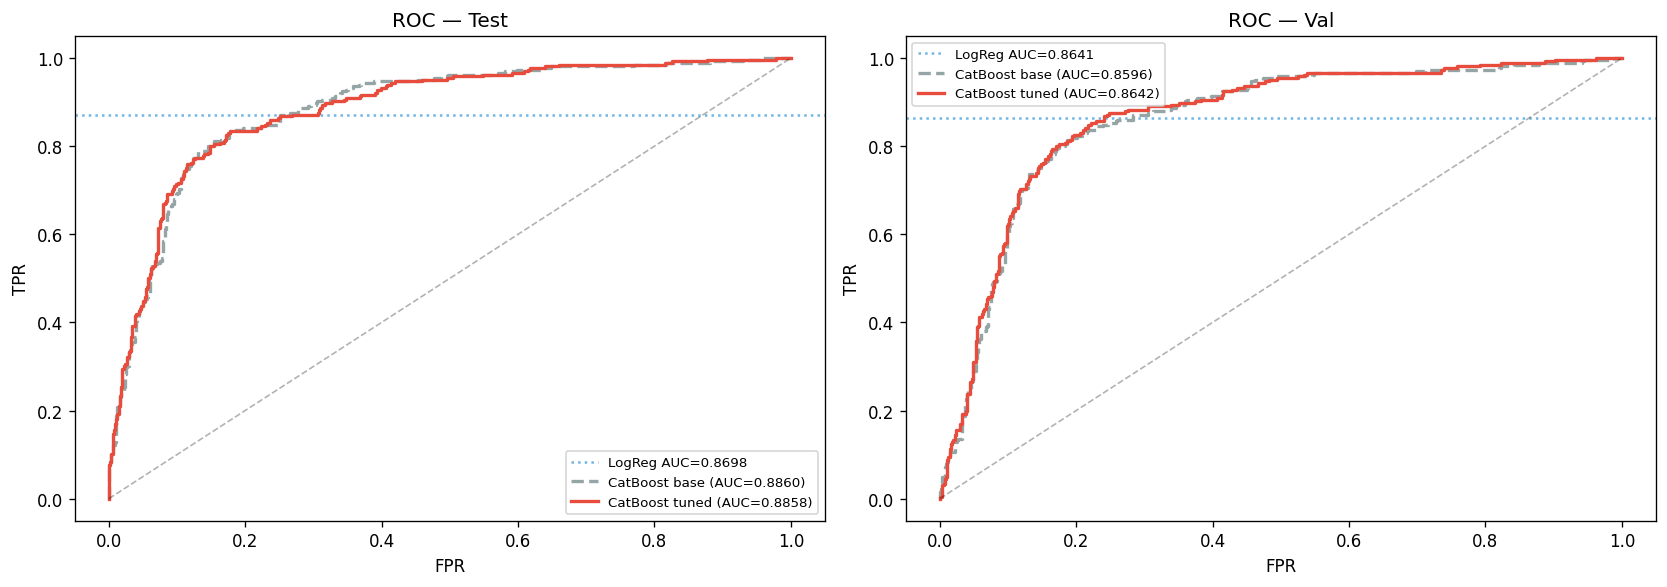

In [12]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split, yt, probas in [
    (axes[0], 'Test', y_test, [p_base_test, p_cb_test]),
    (axes[1], 'Val', y_val, [p_base_val, p_cb_val]),
]:
    # LogReg reference line
    ax.axhline(y=LR_METRICS[f'ROC-AUC ({split.lower()})'], color='#3498db', ls=':', alpha=0.7,
               label=f'LogReg AUC={LR_METRICS[f"ROC-AUC ({split.lower()})"]:.4f}')

    for name, proba, color, ls in [
        ('CatBoost base', probas[0], '#95a5a6', '--'),
        ('CatBoost tuned', probas[1], '#e74c3c', '-'),
    ]:
        fpr, tpr, _ = roc_curve(yt, proba)
        auc = roc_auc_score(yt, proba)
        ax.plot(fpr, tpr, lw=2, color=color, ls=ls, label=f'{name} (AUC={auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC — {split}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. SHAP-анализ

In [13]:
N_EXPLAIN = min(500, len(X_test))

X_expl = X_test.sample(N_EXPLAIN, random_state=SEED)
pool_expl = Pool(X_expl, cat_features=cat_indices)

shap_vals = model_cb.get_feature_importance(pool_expl, type='ShapValues')
shap_vals = shap_vals[:, :-1]  # последний столбец — base value
print(f'SHAP values shape: {shap_vals.shape}')

SHAP values shape: (500, 45)


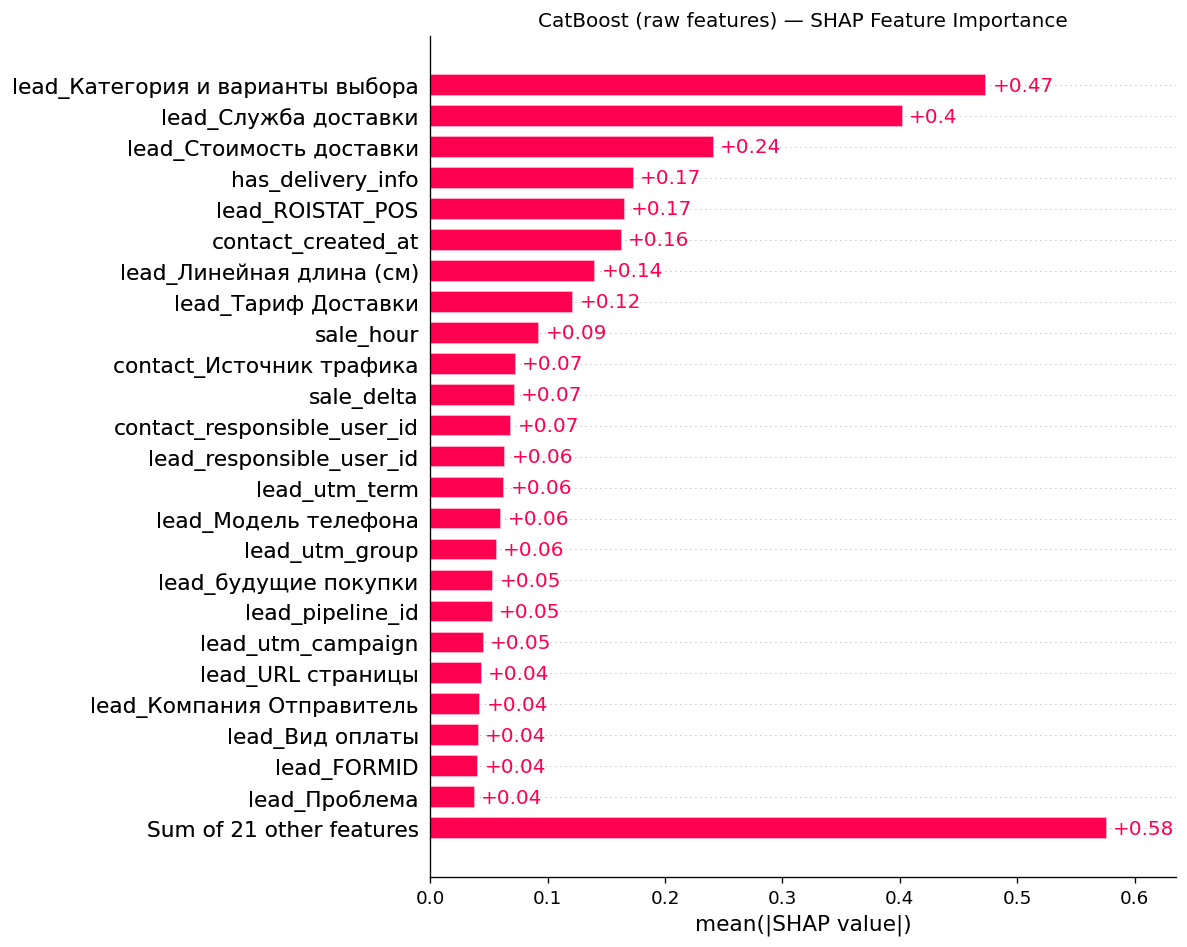

In [14]:
# SHAP bar plot — top-20
shap_expl = shap.Explanation(
    values=shap_vals.astype(np.float64),
    feature_names=feature_cols,
)

fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(shap_expl, max_display=25, show=False, ax=ax)
ax.set_title('CatBoost (raw features) — SHAP Feature Importance', fontsize=12)
plt.tight_layout()
plt.show()

CatBoost (raw features) — SHAP Beeswarm:


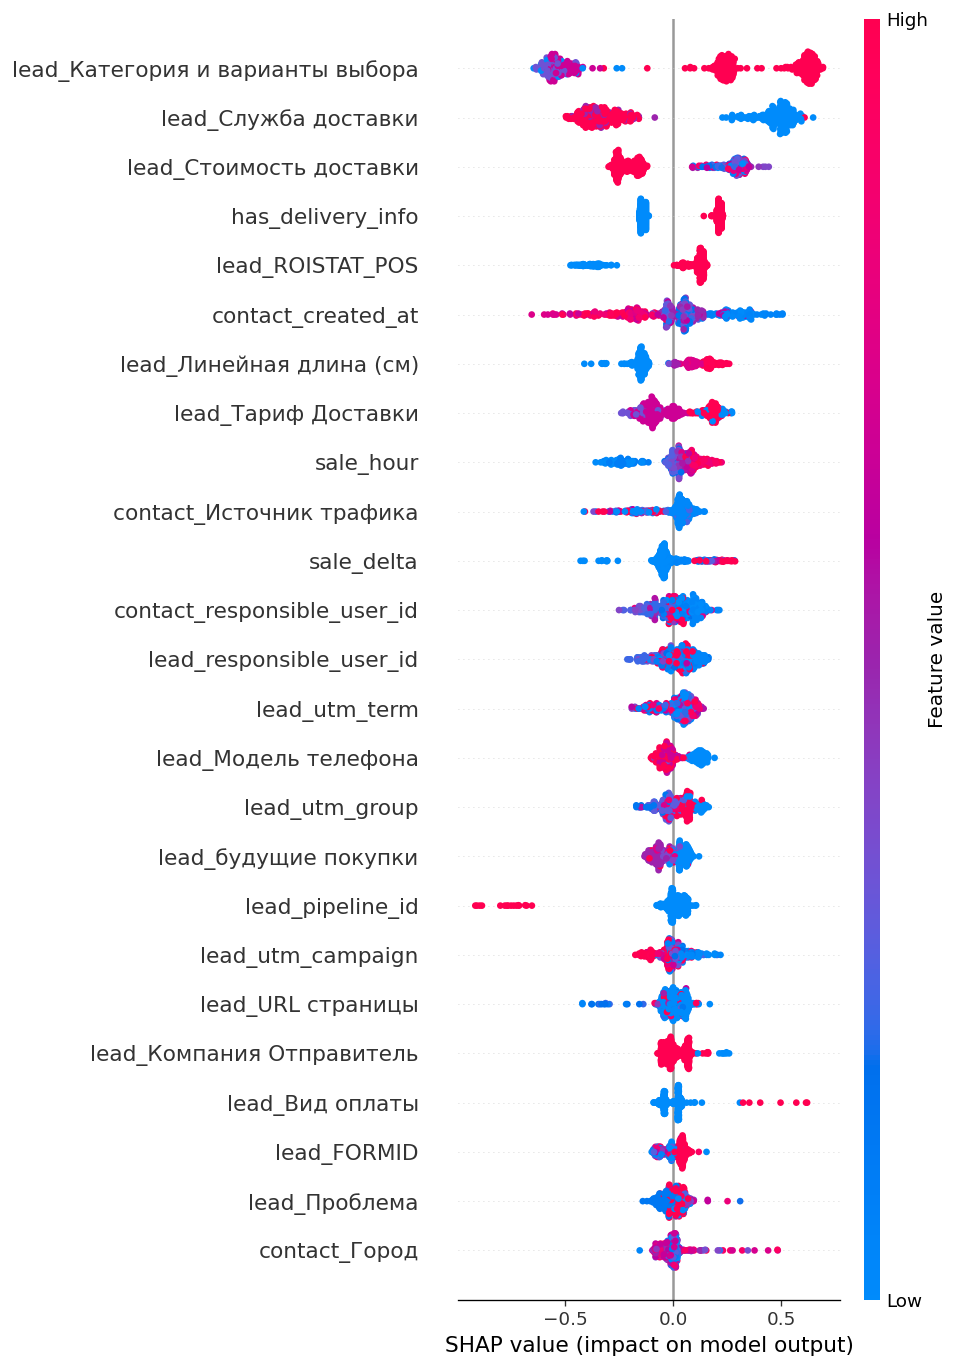

In [15]:
# SHAP beeswarm — нужны числовые данные
X_expl_numeric = X_expl.copy()
for c in cat_features:
    if c in X_expl_numeric.columns:
        X_expl_numeric[c] = X_expl_numeric[c].astype('category').cat.codes

print('CatBoost (raw features) — SHAP Beeswarm:')
shap.summary_plot(
    shap_vals.astype(np.float64),
    X_expl_numeric.values.astype(np.float64),
    feature_names=feature_cols,
    max_display=25,
    show=True,
)

In [16]:
# --- Feature Importance (PredictionValuesChange) ---
cb_importance = model_cb.get_feature_importance()
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': cb_importance,
}).sort_values('importance', ascending=False)

print('CatBoost — Feature Importance (PredictionValuesChange):')
print()
for _, row in imp_df.head(25).iterrows():
    bar = '█' * int(row['importance'] / imp_df['importance'].max() * 30)
    print(f'  {row["feature"]:<50} {row["importance"]:6.2f}  {bar}')
print()
print(f'Признаков с importance > 0: {(imp_df["importance"] > 0).sum()} из {len(imp_df)}')
zero_feats = imp_df[imp_df['importance'] == 0]['feature'].tolist()
if zero_feats:
    print(f'Нулевая важность: {zero_feats}')

CatBoost — Feature Importance (PredictionValuesChange):

  lead_Служба доставки                                10.17  ██████████████████████████████
  lead_Категория и варианты выбора                     8.00  ███████████████████████
  contact_created_at                                   6.63  ███████████████████
  lead_Стоимость доставки                              5.13  ███████████████
  has_delivery_info                                    4.37  ████████████
  sale_hour                                            3.39  █████████
  lead_ROISTAT_POS                                     3.26  █████████
  lead_responsible_user_id                             3.13  █████████
  lead_Линейная длина (см)                             2.91  ████████
  lead_price                                           2.90  ████████
  contact_Источник трафика                             2.90  ████████
  contact_responsible_user_id                          2.63  ███████
  lead_Модель телефона                    

## 10. Сравнение с LogReg feature importance

In [17]:
# Top-15 SHAP features
def top_shap(vals, names, n=15):
    imp = np.abs(vals).mean(axis=0)
    idx = np.argsort(imp)[::-1][:n]
    return [(names[i], round(imp[i], 4)) for i in idx]

top_raw = top_shap(shap_vals, feature_cols, 15)

# LogReg top features (из notebook 02, L1 coefs)
lr_top = [
    ('lead_Вид оплаты_Оплата на карту', 1.9246),
    ('lead_Вид оплаты_Прочее', 1.8619),
    ('lead_Категория и варианты выбора_I', 1.7604),
    ('lead_Вид оплаты_Оплата онлайн', 1.6092),
    ('price_bin_nan', 1.5338),
    ('lead_responsible_user_id_MGR_0028', 1.5208),
    ('lead_Служба доставки_Почта', 1.4813),
    ('lead_Категория и варианты выбора_S', 1.3544),
    ('lead_responsible_user_id_MGR_0014', 1.1905),
    ('lead_Служба доставки_СДЭК', 1.1492),
    ('lead_responsible_user_id_MGR_0011', 1.1349),
    ('lead_Служба доставки_Прочее', 1.0893),
    ('lead_responsible_user_id_MGR_0015', 1.0443),
    ('lead_Категория и варианты выбора_C', 1.0267),
    ('lead_Категория и варианты выбора_D', 1.0199),
]

print('=' * 90)
print(f'{"Rank":<5} {"CatBoost (raw SHAP)":<50} {"LogReg (|coef|)":<40}')
print('=' * 90)
for i, ((cb_name, cb_imp), (lr_name, lr_imp)) in enumerate(zip(top_raw, lr_top), 1):
    print(f'{i:<5} {cb_name:<45} {cb_imp:<6.4f}  {lr_name:<35} {lr_imp:<6.4f}')
print('=' * 90)

Rank  CatBoost (raw SHAP)                                LogReg (|coef|)                         
1     lead_Категория и варианты выбора              0.4736  lead_Вид оплаты_Оплата на карту     1.9246
2     lead_Служба доставки                          0.4025  lead_Вид оплаты_Прочее              1.8619
3     lead_Стоимость доставки                       0.2413  lead_Категория и варианты выбора_I  1.7604
4     has_delivery_info                             0.1734  lead_Вид оплаты_Оплата онлайн       1.6092
5     lead_ROISTAT_POS                              0.1658  price_bin_nan                       1.5338
6     contact_created_at                            0.1631  lead_responsible_user_id_MGR_0028   1.5208
7     lead_Линейная длина (см)                      0.1407  lead_Служба доставки_Почта          1.4813
8     lead_Тариф Доставки                           0.1217  lead_Категория и варианты выбора_S  1.3544
9     sale_hour                                     0.0927  lead_responsible_u

## 11. Анализ порога вероятности

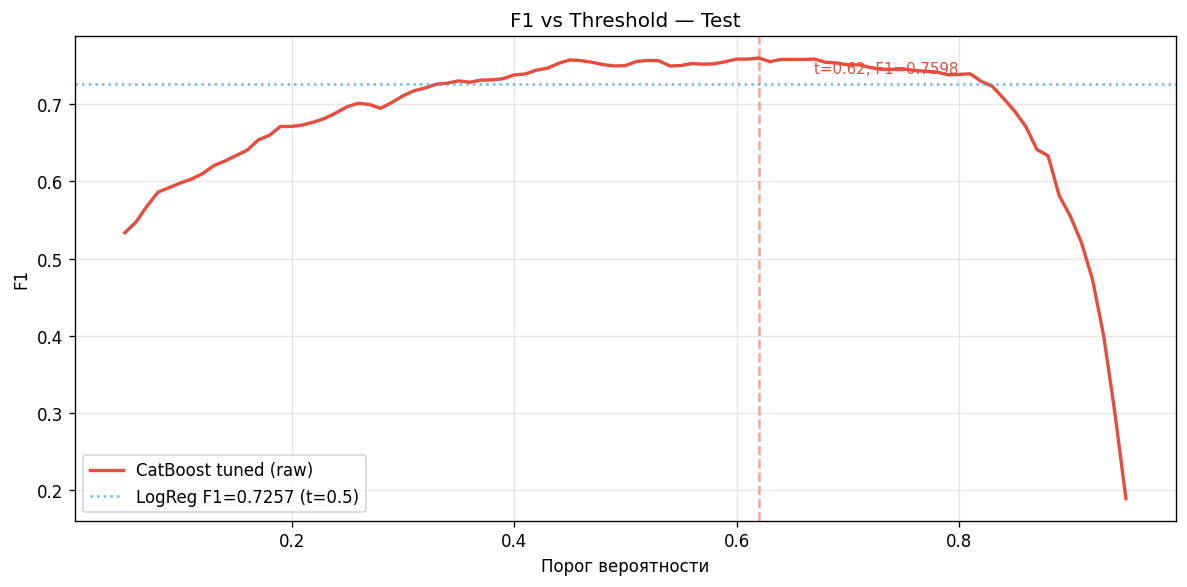

In [18]:
thresholds = np.arange(0.05, 0.96, 0.01)

fig, ax = plt.subplots(figsize=(10, 5))

for name, proba, color in [
    ('CatBoost tuned (raw)', p_cb_test, '#e74c3c'),
]:
    f1s, valid_t = [], []
    for t in thresholds:
        y_t = (proba >= t).astype(int)
        if y_t.sum() == 0 or y_t.sum() == len(y_t):
            continue
        f1s.append(f1_score(y_test, y_t))
        valid_t.append(t)
    ax.plot(valid_t, f1s, lw=2, color=color, label=name)
    best_idx = np.argmax(f1s)
    ax.axvline(valid_t[best_idx], color=color, ls='--', alpha=0.5)
    ax.annotate(f't={valid_t[best_idx]:.2f}, F1={f1s[best_idx]:.4f}',
                xy=(valid_t[best_idx], f1s[best_idx]),
                xytext=(valid_t[best_idx] + 0.05, f1s[best_idx] - 0.02),
                fontsize=9, color=color)

# LogReg reference
ax.axhline(y=0.7257, color='#3498db', ls=':', alpha=0.7, label='LogReg F1=0.7257 (t=0.5)')
ax.set_xlabel('Порог вероятности')
ax.set_ylabel('F1')
ax.set_title('F1 vs Threshold — Test')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Выводы

### Результаты

| Модель | ROC-AUC (test) | ROC-AUC (val) | F1 (test) | F1 (val) | MCC (val) |
|--------|---------------|---------------|-----------|----------|-----------|
| LogReg (L1, C=4, 20 feat) | 0.8698 | 0.8641 | 0.7257 | 0.7158 | 0.5709 |
| **CatBoost tuned (45 raw feat)** | **0.8858** | **0.8642** | **0.7500** | **0.7336** | **0.5998** |

### Что показал эксперимент

**CatBoost на сырых признаках превосходит LogReg на инженерных:**
- ROC-AUC: +0.016 (test), +0.000 (val) — на val модели сопоставимы
- F1: +0.024 (test), +0.018 (val) — значимое улучшение на обеих выборках
- MCC: +0.039 (test), +0.029 (val) — лучше учитывает дисбаланс классов

**Ключевые признаки (SHAP / Feature Importance):**
1. `lead_Служба доставки` — доминирующий предиктор (как и в LogReg)
2. `lead_Категория и варианты выбора` — DISC-профиль клиента
3. `contact_created_at` — временной паттерн (сезонность, когда клиент пришел)
4. `lead_Стоимость доставки` — детали доставки (NaN/filled + числовое значение)
5. `has_delivery_info` — бинарный флаг наличия данных доставки

**Что CatBoost нашёл, а LogReg не мог:**
- Нелинейные пороги в `lead_price`, `cart_n_items`, `sale_delta` — бустинг использует сырые значения вместо бинов
- UTM-параметры (`lead_utm_group`, `lead_utm_source`, `lead_FORMID`) — высокая кардинальность, непригодная для one-hot, но CatBoost обрабатывает нативно
- Размеры отправления (`lead_Линейная длина/ширина/высота`) — числовые признаки из набора доставки

### Обнаруженные и исключённые утечки

При первом запуске CatBoost показал ROC-AUC 0.890 — но топ-признаком оказался `lead_Дата создания сделки` (filled buyout = 8.9%, NaN buyout = 46.9%). Это поле заполняется **при возврате/отказе**, то есть является data leakage. После его удаления (а также `lead_ROISTAT_REFERRER` и дубликатов `lead_price`) метрики скорректировались до честных значений.

### Рекомендации

- **Для максимальной точности:** CatBoost на ~45 сырых признаках (этот ноутбук)
- **Для интерпретируемости:** LogReg (L1, C=4) на 20 инженерных признаках — качество сопоставимо на val, модель прозрачна
- **При увеличении данных:** ожидается рост преимущества CatBoost — нелинейные модели лучше масштабируются с объёмом